# House Price Prediction Model Comparison

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [5]:
df = pd.read_csv("housing.csv")


In [7]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

## Check Dataset Information

In [9]:
print(df.shape)

df.info()

df.describe()

(20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.5+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Separate Features and Target

In [14]:
print(df.columns)
df=pd.read_csv("housing.csv")
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


## Feature Scaling

In [18]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Train Multiple Models

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

## Evaluate Models

In [21]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

## Create Comparison Table

In [22]:
results_df = pd.DataFrame(results).T

print(results_df)

results_df

                           RMSE  R2 Score
Linear Regression  70060.521845  0.625424
Ridge Regression   70057.419085  0.625457
Decision Tree      71452.881461  0.610388


,RMSE,R2 Score
Linear Regression,70060.521845,0.625424
Ridge Regression,70057.419085,0.625457
Decision Tree,71452.881461,0.610388


## Find Best Model

In [23]:
best_model = max(
    results,
    key=lambda x: results[x]["R2 Score"]
)

print("Best Model:", best_model)

Best Model: Ridge Regression


## Visualize Results

In [24]:
best_model_obj = models[best_model]

best_model_obj.fit(X_train, y_train)

y_pred = best_model_obj.predict(X_test)

## Actual vs Predicted Graph

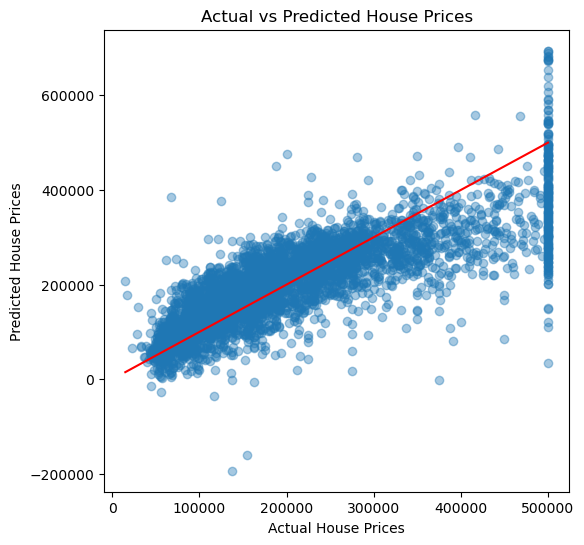

In [25]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")

plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

## Save Best Model

In [26]:
import joblib

joblib.dump(best_model_obj, "best_house_price_model.pkl")

['best_house_price_model.pkl']